In [1]:
# Define the verbose variable
verbose = False

# Check if we're running in a Jupyter Notebook (not compiled script)
try:
    __IPYTHON__
    verbose = True  # Set verbose to True if running in a Jupyter Notebook
except NameError:
    pass  # Do nothing if we're not in a notebook

In [2]:
# All the imports

import torch
from torch.utils.data import TensorDataset
from torch import nn
import matplotlib.pyplot as plt

from the_ml.load_dataset import labelList, get_data
from the_ml.preprocess import preprocess_dataset
from the_ml import bigmodel

from ml_util.eeg_util import plotEEG, plotTimeFreqEEG
from ml_util.checkpoint import checkpoint
from ml_util.data_module import DataModule
from ml_util.trainer import GoodClassificationModel, GoodTrainer
from ml_util.logger import WandBReporter, print_stats

# To make it reproducible
torch.manual_seed(42)

In [3]:
print("Loading raw dataset")
X_raw, y = checkpoint(lambda: get_data(verbose=True), "raw_input")

Loading raw dataset


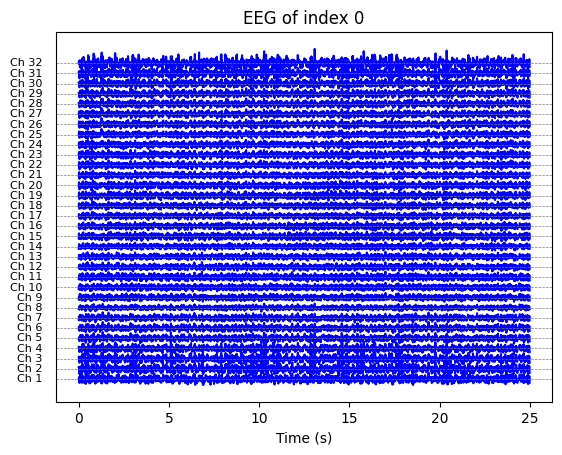

Arithmetic


In [4]:
if verbose:
    plotEEG(X_raw[0], title="index 0")
    print(labelList[y[0]])

In [5]:
hyperparams = {"bands_param": 1} # hop time in seconds

# Applies preprocessing
print("Preprocessing input data")
X = checkpoint(lambda : preprocess_dataset(X_raw, hyperparams["bands_param"], verbose=True), "preprocessed")
print(f"Input dataset shape: {X.shape}")

# Stores in a TensorDataset
dataset = DataModule(X, y, val_part=0.2, test_part=0)

# Uncomment to try overfitting
#dataset = dataset.get_part(0.25)

Preprocessing input data
Input dataset shape: torch.Size([480, 32, 64, 26])


<Figure size 640x480 with 0 Axes>

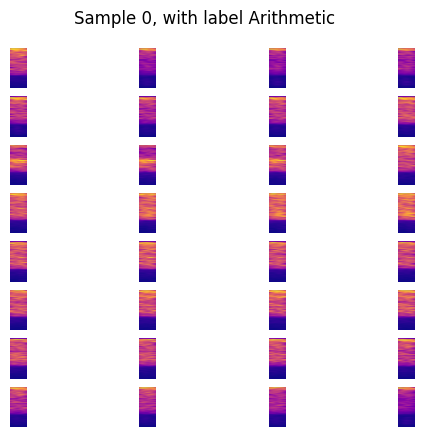

<Figure size 640x480 with 0 Axes>

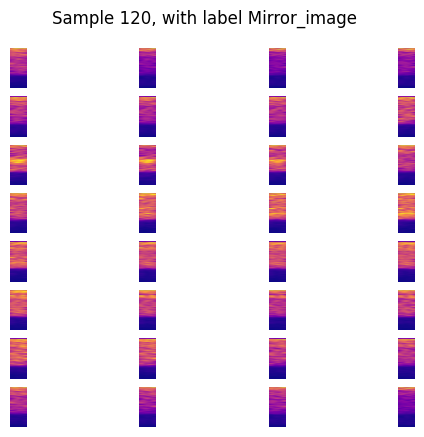

<Figure size 640x480 with 0 Axes>

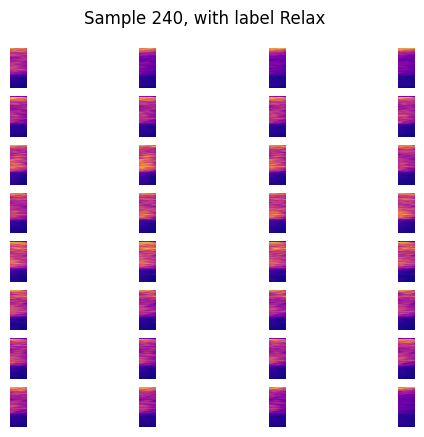

<Figure size 640x480 with 0 Axes>

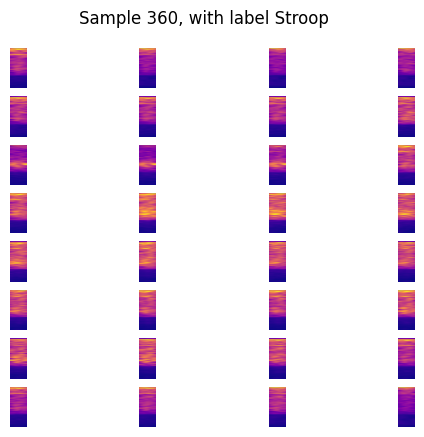

In [6]:
if verbose:
    for label in range(4):
        sampleId = torch.where(y==label)[0][0]
        plt.figure()
        fig, axes = plotTimeFreqEEG(X[sampleId])
        #plt.imshow(X[sampleId][0])
        fig.suptitle(f"Sample {sampleId}, with label {labelList[y[sampleId]]}")
    plt.show()

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("GPU" if torch.cuda.is_available() else "CPU")

hyperparams |= {
    'lr': 2e-4,
    'weight_decay': 2e-4,
    'batch_size': 16
}
model = bigmodel.model(X[0], hyperparams)
loss_fn = nn.CrossEntropyLoss()

classification_model = GoodClassificationModel(model, loss_fn, hyperparams, device, 4)
trainer = GoodTrainer()

def babysitter(goodModel):
    if (goodModel.epoch %  10 == 0):
        goodModel.hyperparameters['lr'] = 0.9 * goodModel.hyperparameters['lr']

trainer.add_babysitter(babysitter)
trainer.add_logger(print_stats)
trainer.add_logger(WandBReporter(hyperparams, labelList, model))

CPU


wandb: Currently logged in as: ulyssedurand (ulyssedurand-ens-de-lyon) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
trainer.train(classification_model, dataset, 1000)

Epoch:    1    | tl: 1.601460, ta: 0.239583    |    vl: 1.377184, va: 0.322917
Epoch:    2    | tl: 1.547085, ta: 0.283854    |    vl: 1.382516, va: 0.322917
Epoch:    3    | tl: 1.483231, ta: 0.255208    |    vl: 1.392368, va: 0.218750
Epoch:    4    | tl: 1.565901, ta: 0.205729    |    vl: 1.394989, va: 0.218750
Epoch:    5    | tl: 1.497914, ta: 0.281250    |    vl: 1.377435, va: 0.322917
Epoch:    6    | tl: 1.518820, ta: 0.223958    |    vl: 1.383960, va: 0.197917
Epoch:    7    | tl: 1.475861, ta: 0.247396    |    vl: 1.377664, va: 0.333333
Epoch:    8    | tl: 1.456203, ta: 0.257812    |    vl: 1.390445, va: 0.208333
Epoch:    9    | tl: 1.429910, ta: 0.268229    |    vl: 1.384551, va: 0.260417
Epoch:   10    | tl: 1.433285, ta: 0.265625    |    vl: 1.382036, va: 0.322917
Epoch:   11    | tl: 1.442323, ta: 0.250000    |    vl: 1.392676, va: 0.229167
Epoch:   12    | tl: 1.398961, ta: 0.278646    |    vl: 1.385078, va: 0.302083
Epoch:   13    | tl: 1.426298, ta: 0.270833    |    

Epoch:  105    | tl: 1.405805, ta: 0.278646    |    vl: 1.378535, va: 0.333333
Epoch:  106    | tl: 1.381593, ta: 0.312500    |    vl: 1.382301, va: 0.322917
Epoch:  107    | tl: 1.391159, ta: 0.273438    |    vl: 1.383646, va: 0.322917
Epoch:  108    | tl: 1.430765, ta: 0.252604    |    vl: 1.379379, va: 0.364583
Epoch:  109    | tl: 1.395691, ta: 0.273438    |    vl: 1.380329, va: 0.322917
Epoch:  110    | tl: 1.407340, ta: 0.242188    |    vl: 1.380303, va: 0.322917
Epoch:  111    | tl: 1.409203, ta: 0.247396    |    vl: 1.379765, va: 0.322917
Epoch:  112    | tl: 1.379993, ta: 0.289062    |    vl: 1.376902, va: 0.322917
Epoch:  113    | tl: 1.391416, ta: 0.270833    |    vl: 1.378940, va: 0.354167
Epoch:  114    | tl: 1.414447, ta: 0.270833    |    vl: 1.378022, va: 0.312500
Epoch:  115    | tl: 1.405627, ta: 0.263021    |    vl: 1.387173, va: 0.270833
Epoch:  116    | tl: 1.397381, ta: 0.263021    |    vl: 1.385241, va: 0.229167
Epoch:  117    | tl: 1.400600, ta: 0.255208    |    

Epoch:  209    | tl: 1.410688, ta: 0.239583    |    vl: 1.384405, va: 0.343750
Epoch:  210    | tl: 1.389847, ta: 0.231771    |    vl: 1.386080, va: 0.312500
Epoch:  211    | tl: 1.391874, ta: 0.283854    |    vl: 1.387684, va: 0.291667
Epoch:  212    | tl: 1.388693, ta: 0.270833    |    vl: 1.388016, va: 0.302083
Epoch:  213    | tl: 1.371538, ta: 0.315104    |    vl: 1.382764, va: 0.354167
Epoch:  214    | tl: 1.380202, ta: 0.289062    |    vl: 1.386420, va: 0.322917
Epoch:  215    | tl: 1.370532, ta: 0.309896    |    vl: 1.388612, va: 0.260417
Epoch:  216    | tl: 1.403585, ta: 0.265625    |    vl: 1.383734, va: 0.364583
Epoch:  217    | tl: 1.381360, ta: 0.263021    |    vl: 1.388057, va: 0.302083
Epoch:  218    | tl: 1.392961, ta: 0.291667    |    vl: 1.391461, va: 0.177083
Epoch:  219    | tl: 1.374220, ta: 0.273438    |    vl: 1.388484, va: 0.322917
Epoch:  220    | tl: 1.393964, ta: 0.255208    |    vl: 1.387939, va: 0.333333
Epoch:  221    | tl: 1.375772, ta: 0.302083    |    